In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sms
import pandas as pd

%matplotlib inline

In [2]:
df_airline=pd.read_csv('airline_passengers.csv')
df_airline.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [3]:
df_airline.isnull().sum()

Month                      0
Thousands of Passengers    1
dtype: int64

In [4]:
df_airline.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [5]:
df_airline.dropna(axis=0,inplace=True)

In [6]:
df_airline.isnull().sum()

Month                      0
Thousands of Passengers    0
dtype: int64

In [7]:
df_airline.info() 
# month should be in datetime format

<class 'pandas.core.frame.DataFrame'>
Int64Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [8]:
df_airline['Month']=pd.to_datetime(df_airline['Month'])

In [9]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Month                    144 non-null    datetime64[ns]
 1   Thousands of Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.4 KB


In [10]:
df_airline.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [11]:
df_airline.set_index('Month',inplace=True)

In [12]:
df_airline.head()

,Thousands of Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


<AxesSubplot:xlabel='Month'>

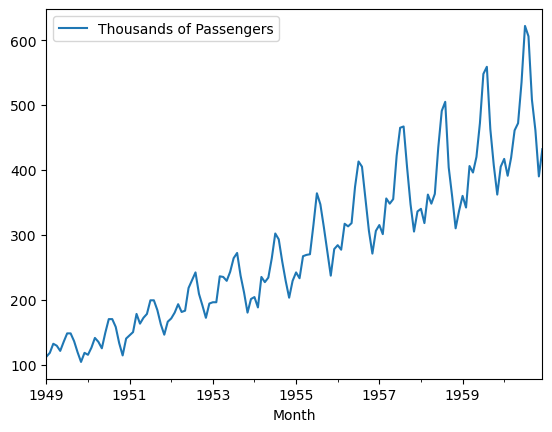

In [13]:
df_airline.plot() 
# this is seasonal data

In [14]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [15]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [16]:
adf_test(df_airline['Thousands of Passengers'])

ADF Statistics: 0.8153688792060423
p- value: 0.9918802434376409
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [17]:
## Use Techniques Differencing -- one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df_airline['Passengers First Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(1)

In [18]:
df_airline.head()

,Thousands of Passengers,Passengers First Difference
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [19]:
adf_test(df_airline['Passengers First Difference'].dropna())

ADF Statistics: -2.8292668241699874
p- value: 0.05421329028382711
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [20]:
## Use Techniques Differencing
df_airline['Passengers Second Difference']=df_airline['Passengers First Difference']-df_airline['Passengers First Difference'].shift(1)

In [21]:
adf_test(df_airline['Passengers Second Difference'].dropna())

ADF Statistics: -16.384231542468513
p- value: 2.7328918500142026e-29
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [22]:
### 12 months 
## Use Techniques Differencing
df_airline['Passengers 12 Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(12)

In [23]:
adf_test(df_airline['Passengers 12 Difference'].dropna())

ADF Statistics: -3.3830207264924805
p- value: 0.011551493085514982
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [24]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

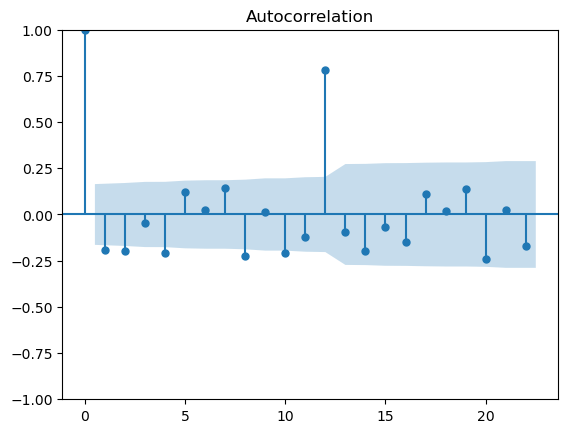

In [25]:
acf = plot_acf(df_airline["Passengers Second Difference"].dropna())
# q = 7

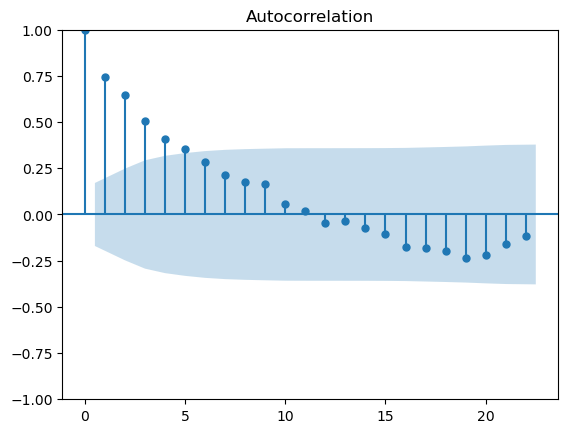

In [26]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
# q = 5

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


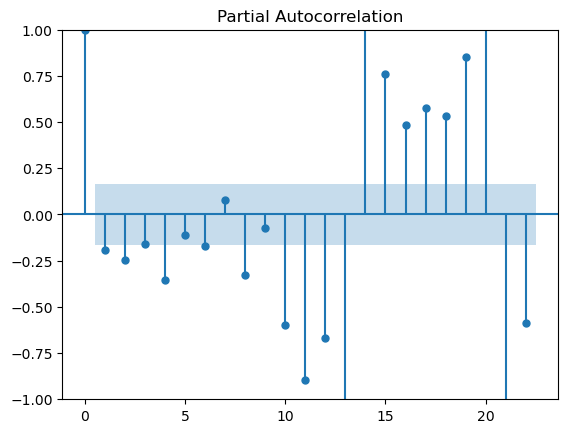

In [27]:
pacf = plot_pacf(df_airline["Passengers Second Difference"].dropna())
# p = 2 and p =10
# 1st I go for p=2 and the go for p=10

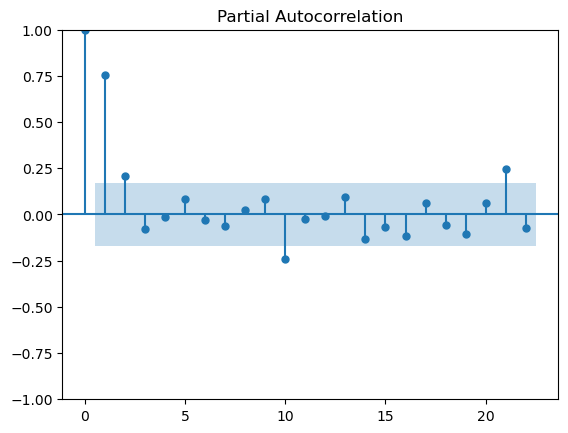

In [28]:
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

In [29]:
### split train and test data
df_airline

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1960-08-01,606.0,-16.0,-103.0,47.0
1960-09-01,508.0,-98.0,-82.0,45.0
1960-10-01,461.0,-47.0,51.0,54.0


In [30]:
from datetime import datetime,timedelta
train_dataset_end=datetime(1955,12,1)
test_dataset_end=datetime(1960,12,1)

In [31]:
train_data=df_airline[:train_dataset_end]
test_data=df_airline[train_dataset_end+timedelta(days=1):test_dataset_end]

In [32]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [33]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [34]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [35]:
train_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1955-08-01,347.0,-17.0,-66.0,54.0
1955-09-01,312.0,-35.0,-18.0,53.0
1955-10-01,274.0,-38.0,-3.0,45.0


In [36]:
model_ARIMA=ARIMA(train_data['Thousands of Passengers'],order=( 4,2,3))

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [37]:
model_Arima_fit=model_ARIMA.fit()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [38]:
model_Arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                      ARIMA(4, 2, 3)   Log Likelihood                -355.974
Date:                     Sun, 13 Nov 2022   AIC                            727.949
Time:                             22:13:57   BIC                            747.202
Sample:                         01-01-1949   HQIC                           735.679
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3331      0.134     -2.491      0.013      -0.595      -0.071
ar.L2         -0.8535      0.134     -6.370      0.000      -1.116      -0.591
ar.L3          0.1163      0.135      0.864      0.387      -0.148       0.380
ar.L4         -0.4245      0.134     -3.164      0.002      -0.687      -0.162
ma.L1         -0.2988     35.619     -0.008      0.993     -70.110      69.512
ma.L2          0.2859     24.972      0.011      0.991     -48.657      49.229
ma.L3         -0.9869     35.217     -0.028      0.978     -70.011      68.037
sigma2       306.4331   1.09e+04      0.028      0.978   -2.11e+04    2.17e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):                 0.51
Prob(Q):                              0.60   Prob(JB):                         0.77
Heteroskedasticity (H):               3.64   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [39]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [40]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [41]:
pred=model_Arima_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Thousands of Passengers']-pred

In [42]:
pred

1956-01-01    302.945432
1956-02-01    293.258343
1956-03-01    300.873105
1956-04-01    297.308100
1956-05-01    285.485066
1956-06-01    302.666838
1956-07-01    308.591777
1956-08-01    297.295654
1956-09-01    308.222225
1956-10-01    312.824191
1956-11-01    303.340610
1956-12-01    313.841207
1957-01-01    319.539204
1957-02-01    310.826553
1957-03-01    319.316060
1957-04-01    325.334225
1957-05-01    317.855827
1957-06-01    325.099798
1957-07-01    331.370261
1957-08-01    324.878565
1957-09-01    330.909785
1957-10-01    337.300068
1957-11-01    331.811220
1957-12-01    336.846266
1958-01-01    343.241127
1958-02-01    338.666778
1958-03-01    342.851775
1958-04-01    349.172614
1958-05-01    345.452865
1958-06-01    348.929346
1958-07-01    355.108980
1958-08-01    352.171804
1958-09-01    355.062988
1958-10-01    361.053960
1958-11-01    358.830137
1958-12-01    361.244489
1959-01-01    367.011928
1959-02-01    365.432589
1959-03-01    367.464808
1959-04-01    372.985858


In [43]:
residuals

Month
1956-01-01    -18.945432
1956-02-01    -16.258343
1956-03-01     16.126895
1956-04-01     15.691900
1956-05-01     32.514934
1956-06-01     71.333162
1956-07-01    104.408223
1956-08-01    107.704346
1956-09-01     46.777775
1956-10-01     -6.824191
1956-11-01    -32.340610
1956-12-01     -7.841207
1957-01-01     -4.539204
1957-02-01     -9.826553
1957-03-01     36.683940
1957-04-01     22.665775
1957-05-01     37.144173
1957-06-01     96.900202
1957-07-01    133.629739
1957-08-01    142.121435
1957-09-01     73.090215
1957-10-01      9.699932
1957-11-01    -26.811220
1957-12-01     -0.846266
1958-01-01     -3.241127
1958-02-01    -20.666778
1958-03-01     19.148225
1958-04-01     -1.172614
1958-05-01     17.547135
1958-06-01     86.070654
1958-07-01    135.891020
1958-08-01    152.828196
1958-09-01     48.937012
1958-10-01     -2.053960
1958-11-01    -48.830137
1958-12-01    -24.244489
1959-01-01     -7.011928
1959-02-01    -23.432589
1959-03-01     38.535192
1959-04-01     23.0

<AxesSubplot:ylabel='Density'>

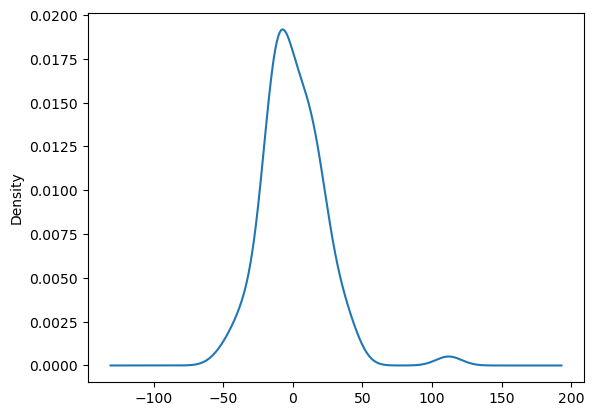

In [44]:
model_Arima_fit.resid.plot(kind='kde')

In [45]:
test_data['Predicted_ARIMA']=pred

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_14352\95659616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA']=pred


<AxesSubplot:xlabel='Month'>

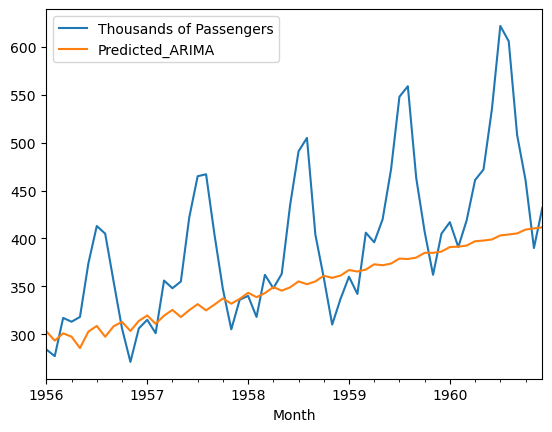

In [46]:
test_data[['Thousands of Passengers','Predicted_ARIMA']].plot()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


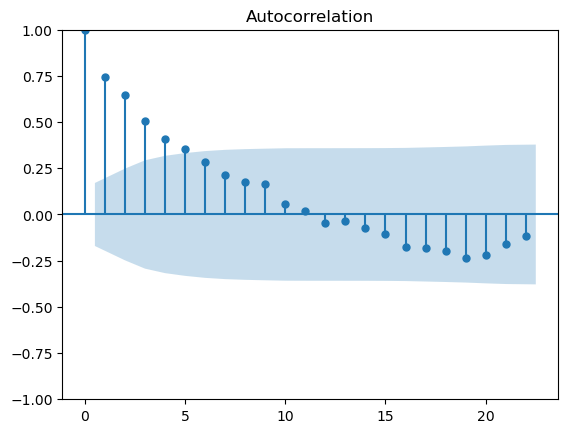

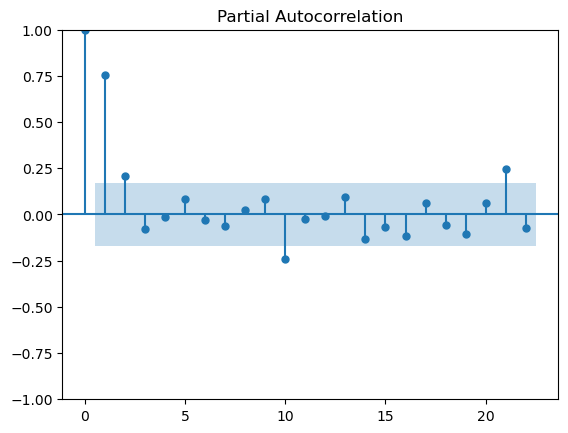

In [47]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

In [48]:
## create a SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [49]:
model_SARIMA=SARIMAX(train_data['Thousands of Passengers'],order=(3,0,5),seasonal_order=(0,1,0,12))

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [50]:
model_SARIMA_fit=model_SARIMA.fit()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [51]:
model_SARIMA_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(0, 1, [], 12)   Log Likelihood                -265.240
Date:                             Sun, 13 Nov 2022   AIC                            548.481
Time:                                     22:13:59   BIC                            568.971
Sample:                                 01-01-1949   HQIC                           556.638
                                      - 12-01-1955                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5982      0.938      0.638      0.524      -1.240       2.436
ar.L2          0.8311      0.232      3.581      0.000       0.376       1.286
ar.L3         -0.4524      0.894     -0.506      0.613      -2.204       1.300
ma.L1          0.1838      1.164      0.158      0.875      -2.098       2.466
ma.L2         -0.5341      1.262     -0.423      0.672      -3.008       1.940
ma.L3         -0.0987      0.384     -0.257      0.797      -0.852       0.654
ma.L4         -0.1273      0.337     -0.377      0.706      -0.789       0.534
ma.L5          0.2471      0.357      0.693      0.489      -0.452       0.946
sigma2        87.7327     81.160      1.081      0.280     -71.337     246.803
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.68
Prob(Q):                              0.88   Prob(JB):                         0.26
Heteroskedasticity (H):               2.05   Skew:                             0.46
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
test_data.tail()

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA
Month,,,,,
1960-08-01,606.0,-16.0,-103.0,47.0,404.156352
1960-09-01,508.0,-98.0,-82.0,45.0,405.247685
1960-10-01,461.0,-47.0,51.0,54.0,409.231828
1960-11-01,390.0,-71.0,-24.0,28.0,410.503228
1960-12-01,432.0,42.0,113.0,27.0,411.579558


In [53]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [54]:
pred_Sarima=model_SARIMA_fit.predict(start=datetime(1956,6,6),end=datetime(1960,12,1))
residuals=test_data['Thousands of Passengers']-pred_Sarima

<AxesSubplot:xlabel='Month'>

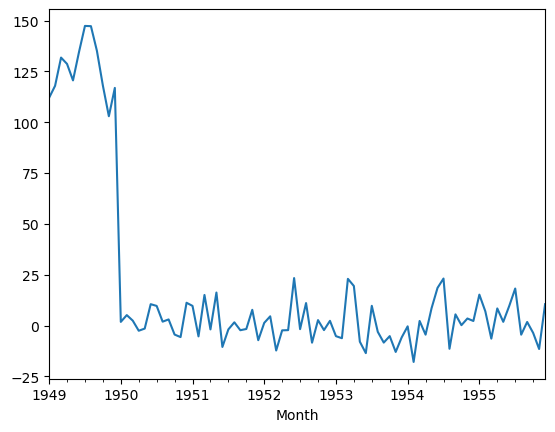

In [55]:
model_SARIMA_fit.resid.plot()

<AxesSubplot:ylabel='Density'>

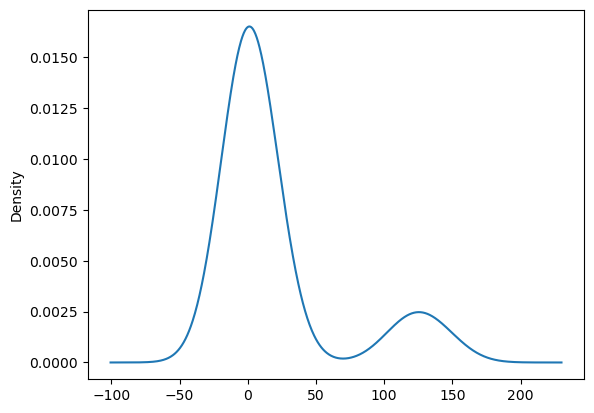

In [56]:
model_SARIMA_fit.resid.plot(kind='kde')

In [57]:
test_data['Predicted_SARIMA']=pred_Sarima

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_14352\1367177785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_SARIMA']=pred_Sarima


In [58]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA,Predicted_SARIMA
Month,,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,302.945432,NaN
1956-02-01,277.0,-7.0,-13.0,44.0,293.258343,NaN
1956-03-01,317.0,40.0,47.0,50.0,300.873105,NaN
1956-04-01,313.0,-4.0,-44.0,44.0,297.308100,NaN
1956-05-01,318.0,5.0,9.0,48.0,285.485066,NaN
1956-06-01,374.0,56.0,51.0,59.0,302.666838,NaN
1956-07-01,413.0,39.0,-17.0,49.0,308.591777,403.398209
1956-08-01,405.0,-8.0,-47.0,58.0,297.295654,385.071409
1956-09-01,355.0,-50.0,-42.0,43.0,308.222225,349.445783


<AxesSubplot:xlabel='Month'>

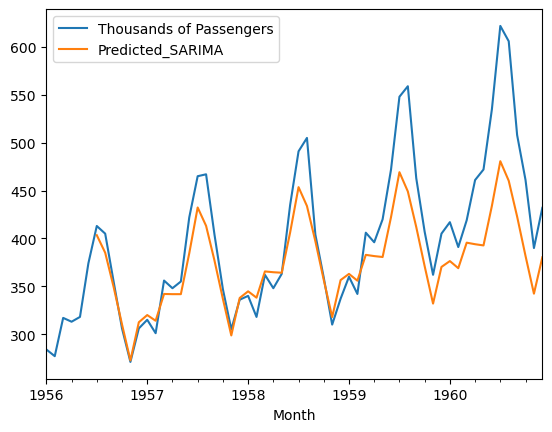

In [59]:
test_data[['Thousands of Passengers','Predicted_SARIMA']].plot()